In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/home/mynk/Machine_learning_journey/Datasets/Instagram visits clustering.csv')

df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [4]:
df.drop(columns=["User ID"], inplace=True)

df.head()

,Instagram visit score,Spending_rank(0 to 100)
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


In [5]:
df.shape

(2600, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Instagram visit score    2600 non-null   int64  
 1   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 40.8 KB


In [7]:
df.describe()

,Instagram visit score,Spending_rank(0 to 100)
count,2600.000000,2600.000000
mean,63.323462,42.848408
std,26.579760,28.758349
min,5.000000,0.940709
25%,38.000000,19.452098
50%,72.000000,28.013082
75%,86.000000,72.116945
max,118.000000,107.349821


In [8]:
df.isnull().sum()

Instagram visit score      0
Spending_rank(0 to 100)    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

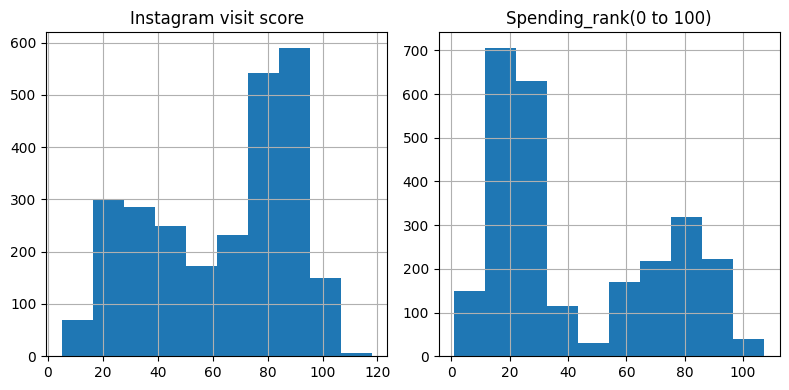

In [10]:
df.hist(figsize=(8,4))
plt.tight_layout()
plt.show()

/tmp/ipykernel_16156/2409438216.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df.values,


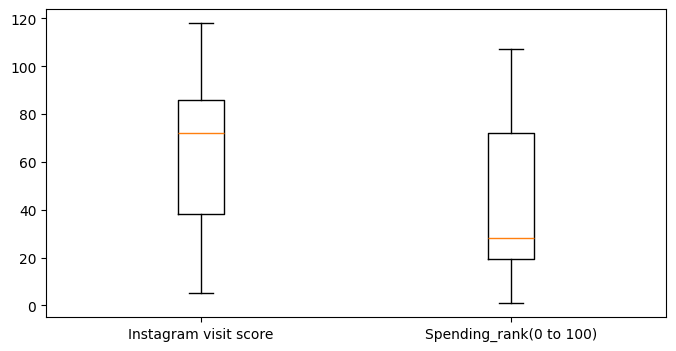

In [11]:
plt.figure(figsize=(8,4))

plt.boxplot(df.values,
            labels=df.columns)

plt.show()

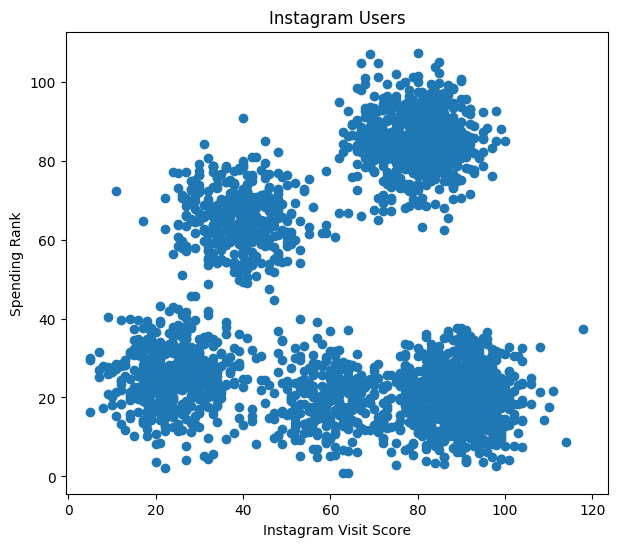

In [14]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["Instagram visit score"],
    df["Spending_rank(0 to 100)"]
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")
plt.title("Instagram Users")

plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

X[:5]

array([[-0.01217181, -0.65376894],
       [-0.08743151, -0.61298749],
       [ 1.53065202, -0.84583579],
       [ 0.70279533,  1.53173941],
       [-1.85603443, -0.39495297]])

In [16]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

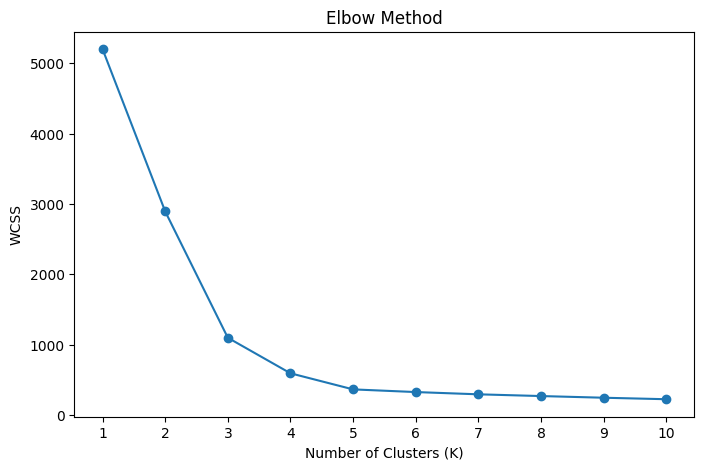

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.xticks(range(1,11))

plt.show()

In [18]:
from sklearn.metrics import silhouette_score

In [19]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

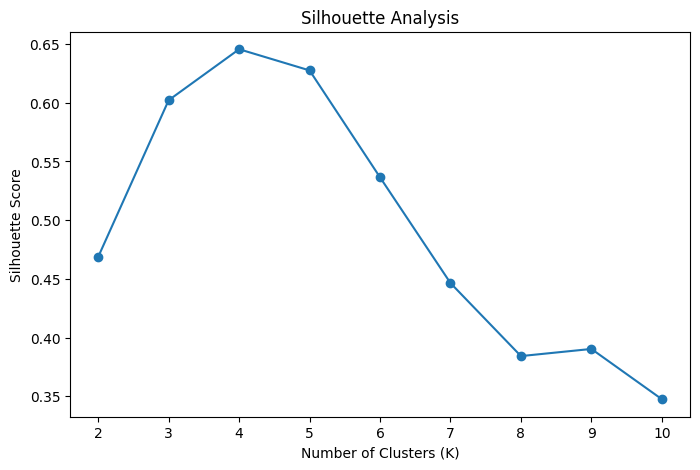

In [20]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.xticks(range(2,11))

plt.show()

In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

In [22]:
df["Cluster"] = clusters

df.head()

,Instagram visit score,Spending_rank(0 to 100),Cluster
0,63,24.050708,0
1,61,25.223290,0
2,104,18.528245,0
3,82,86.890232,2
4,14,31.492397,3


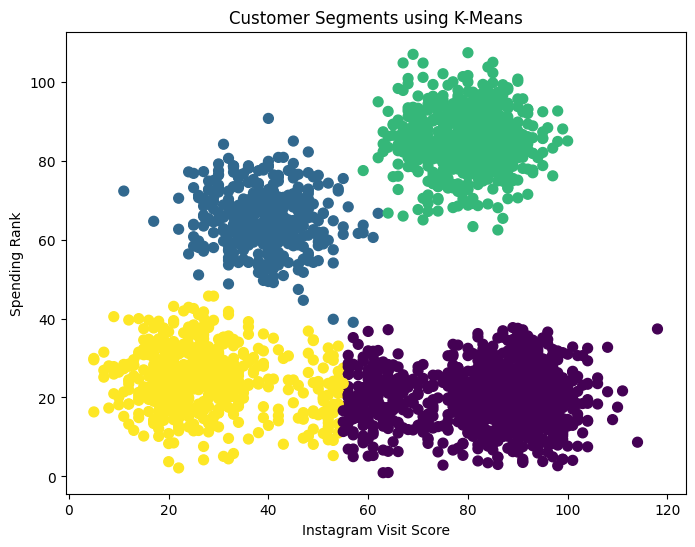

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Instagram visit score"],
    df["Spending_rank(0 to 100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")
plt.title("Customer Segments using K-Means")

plt.show()

In [25]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

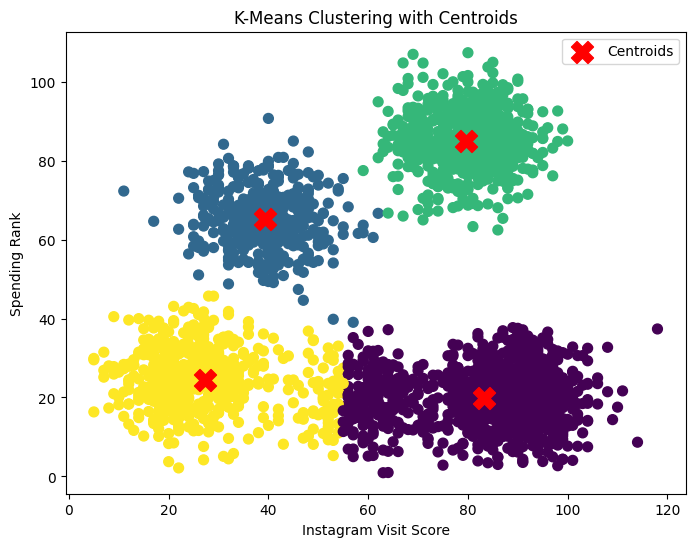

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Instagram visit score"],
    df["Spending_rank(0 to 100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")
plt.title("K-Means Clustering with Centroids")

plt.legend()

plt.show()

In [28]:
new_user = [[75, 82]]

In [29]:
new_user_scaled = scaler.transform(new_user)

/home/mynk/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [30]:
predicted_cluster = kmeans.predict(new_user_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


In [39]:
cluster_names = {
    0: "Highly Engaged Browsers",
    1: "Potential Loyal Customers",
    2: "Premium Customers",
    3: "Inactive Users"
}

In [40]:
def predict_customer(instagram_score, spending_rank):
    new_data = [[instagram_score, spending_rank]]

    new_data_scaled = scaler.transform(new_data)

    cluster = kmeans.predict(new_data_scaled)[0]

    print(f"Predicted Cluster: {cluster}")
    print(f"Customer Segment: {cluster_names[cluster]}")

In [41]:
predict_customer(85, 90)

Predicted Cluster: 2
Customer Segment: Premium Customers


/home/mynk/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [45]:
predict_customer(20, 15)

Predicted Cluster: 3
Customer Segment: Inactive Users


/home/mynk/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
df.groupby("Cluster").mean()

,Instagram visit score,Spending_rank(0 to 100)
Cluster,,
0,83.243427,19.872486
1,39.350000,65.132485
2,79.615000,85.024498
3,27.296684,24.309119


In [47]:
df.groupby("Cluster").agg({
    "Instagram visit score": "mean",
    "Spending_rank(0 to 100)": "mean"
})

,Instagram visit score,Spending_rank(0 to 100)
Cluster,,
0,83.243427,19.872486
1,39.350000,65.132485
2,79.615000,85.024498
3,27.296684,24.309119
